### Problem Statement 1

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB

In [2]:
iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target column
df['species'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

In [4]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

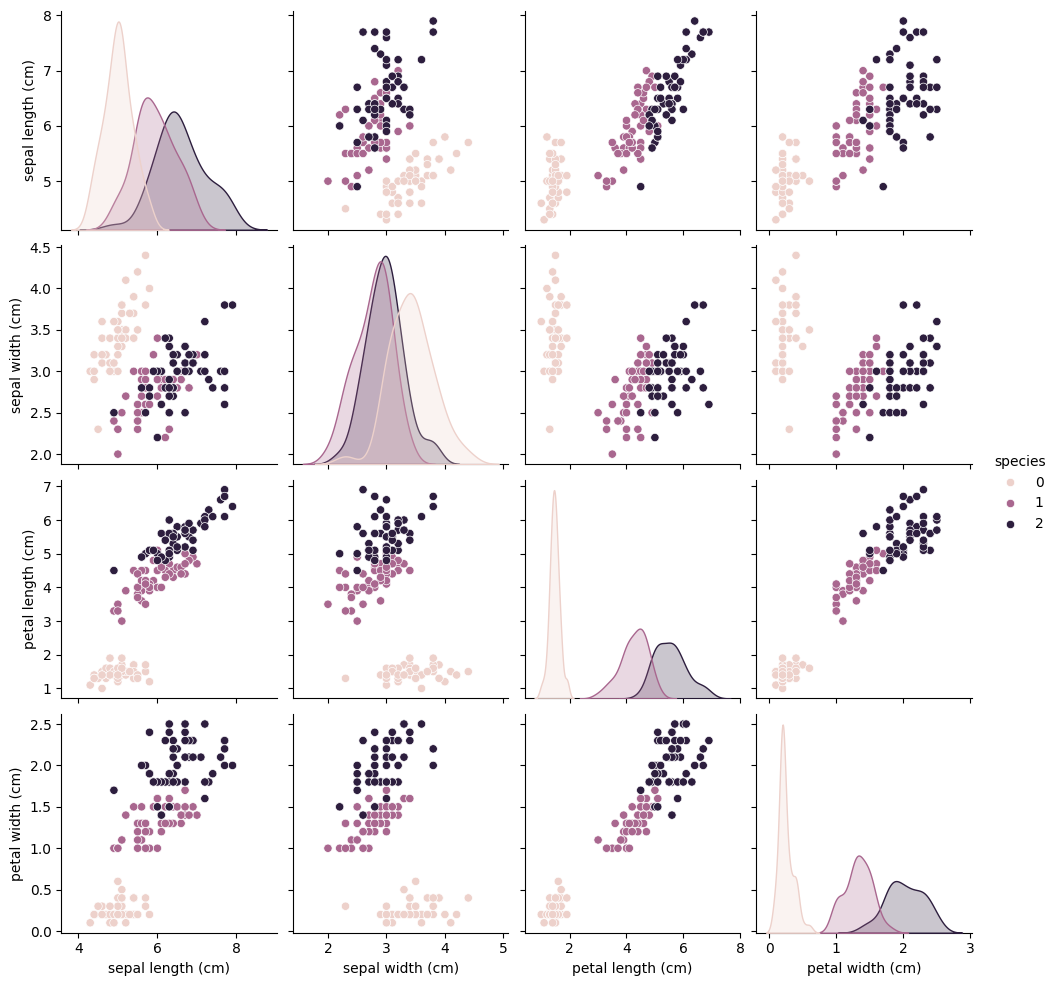

In [6]:
sns.pairplot(df, hue='species')
plt.show()

In [11]:
class GaussianNB_Scratch:
    
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.priors = {}
        
        for c in self.classes:
            X_c = X[y == c]
            
            self.mean[c] = np.mean(X_c, axis=0)
            self.var[c] = np.var(X_c, axis=0)
            
            self.priors[c] = X_c.shape[0] / X.shape[0]

    def gaussian_pdf(self, class_idx, x):
        
        mean = self.mean[class_idx]
        var = self.var[class_idx]
        
        numerator = np.exp(-(x-mean)**2/(2*var))
        denominator = np.sqrt(2*np.pi*var)
        
        return numerator/denominator

    def predict(self, X):
        predictions = []
        
        for x in X.values:
            posteriors = []
            
            for c in self.classes:
                
                prior = np.log(self.priors[c])
                likelihood = np.sum(np.log(self.gaussian_pdf(c, x)))
                
                posterior = prior + likelihood
                
                posteriors.append(posterior)
            
            predictions.append(self.classes[np.argmax(posteriors)])
        
        return np.array(predictions)

In [12]:
model = GaussianNB_Scratch()
model.fit(X_train, y_train)

y_pred_custom = model.predict(X_test)

In [14]:
gnb = GaussianNB()

gnb.fit(X_train, y_train)

y_pred_sklearn = gnb.predict(X_test)

In [15]:
print("Custom Model Accuracy:",
      accuracy_score(y_test, y_pred_custom))

print("Sklearn Model Accuracy:",
      accuracy_score(y_test, y_pred_sklearn))

Custom Model Accuracy: 1.0
Sklearn Model Accuracy: 1.0


In [16]:
print("Precision:",
      precision_score(y_test, y_pred_sklearn, average='macro'))

Precision: 1.0


In [17]:
print("Recall:",
      recall_score(y_test, y_pred_sklearn, average='macro'))

Recall: 1.0


In [19]:
cm = confusion_matrix(y_test, y_pred_sklearn)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [20]:
print(classification_report(y_test, y_pred_sklearn))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Problem Statement 2

In [3]:
# 1. Import required libraries
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [4]:
# 2. Load Iris dataset and extract first two features
iris = load_iris()
X = iris.data[:, :2]   # sepal length and sepal width

In [5]:
# 3. Implement K-Means class
class KMeans:

    def __init__(self, n_clusters=3, max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    # Fit model and return cluster labels
    def fit_predict(self, X):

        # Initialize random centroids
        random_index = random.sample(range(0, X.shape[0]), self.n_clusters)
        self.centroids = X[random_index]

        for i in range(self.max_iter):

            # Assign clusters
            cluster_group = self.assign_clusters(X)

            old_centroids = self.centroids

            # Update centroids
            self.centroids = self.move_centroids(X, cluster_group)

            # Check convergence
            if (old_centroids == self.centroids).all():
                break

        return cluster_group


    # 4. Euclidean distance and cluster assignment
    def assign_clusters(self, X):

        cluster_group = []
        distances = []

        for row in X:

            for centroid in self.centroids:

                distance = np.sqrt(np.dot(row-centroid, row-centroid))
                distances.append(distance)

            min_distance = min(distances)
            index_pos = distances.index(min_distance)

            cluster_group.append(index_pos)
            distances.clear()

        return np.array(cluster_group)


    # 6. Update centroids
    def move_centroids(self, X, cluster_group):

        new_centroids = []

        cluster_type = np.unique(cluster_group)

        for type in cluster_type:

            new_centroid = X[cluster_group == type].mean(axis=0)
            new_centroids.append(new_centroid)

        return np.array(new_centroids)





In [6]:
# Function to visualize clusters
def plot_clusters(X, labels, centroids, K):

    plt.figure(figsize=(6,5))

    for i in range(K):
        points = X[labels == i]
        plt.scatter(points[:,0], points[:,1], label=f"Cluster {i}")

    plt.scatter(centroids[:,0], centroids[:,1],
                c='black', marker='X', s=200, label='Centroids')

    plt.xlabel("Sepal Length")
    plt.ylabel("Sepal Width")
    plt.title(f"K-Means Clustering (K = {K})")
    plt.legend()
    plt.show()



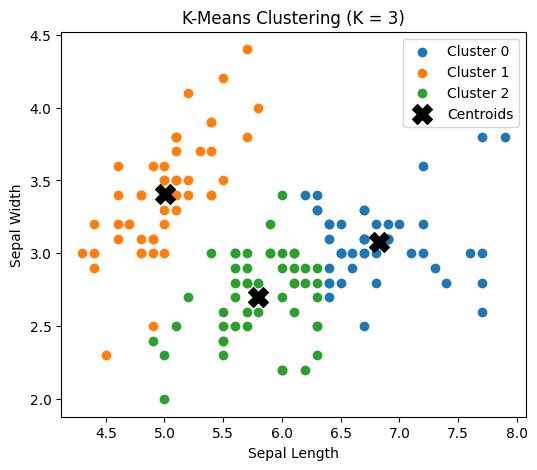

In [7]:
# 7. Run algorithm with K = 3
model3 = KMeans(n_clusters=3)
labels3 = model3.fit_predict(X)

plot_clusters(X, labels3, model3.centroids, 3)

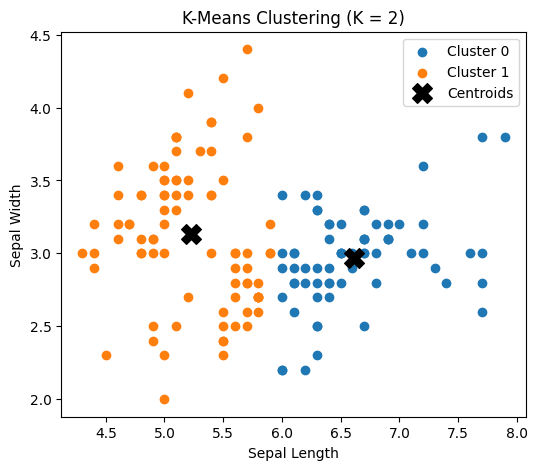

In [8]:
# Run algorithm with K = 2
model2 = KMeans(n_clusters=2)
labels2 = model2.fit_predict(X)

plot_clusters(X, labels2, model2.centroids, 2)

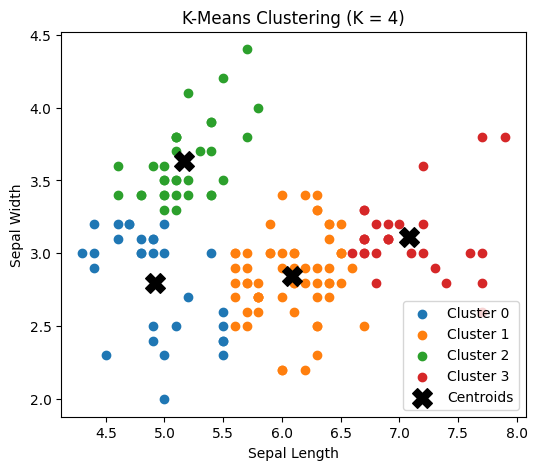

In [9]:
# Run algorithm with K = 4
model4 = KMeans(n_clusters=4)
labels4 = model4.fit_predict(X)

plot_clusters(X, labels4, model4.centroids, 4)

### Problem Statement 3

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN

In [29]:
datasets = [
    "cluster_blobs.csv",
    "cluster_moons.csv",
    "cluster_circles.csv"
]


Dataset: cluster_blobs.csv


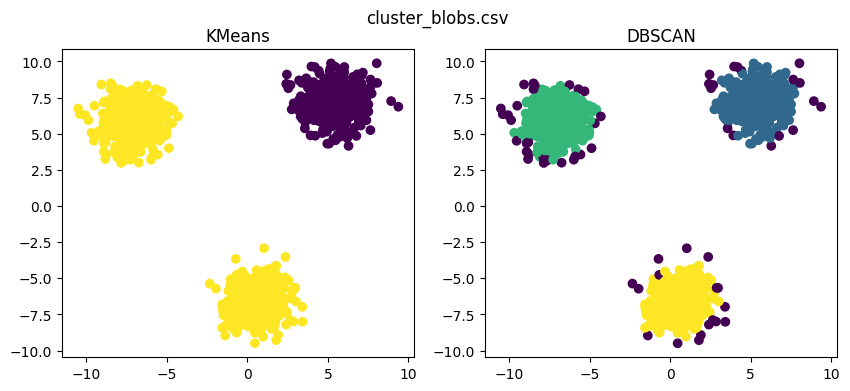


Dataset: cluster_moons.csv


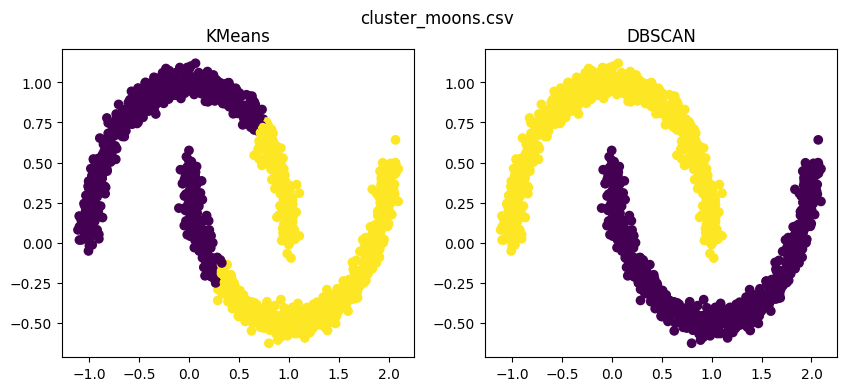


Dataset: cluster_circles.csv


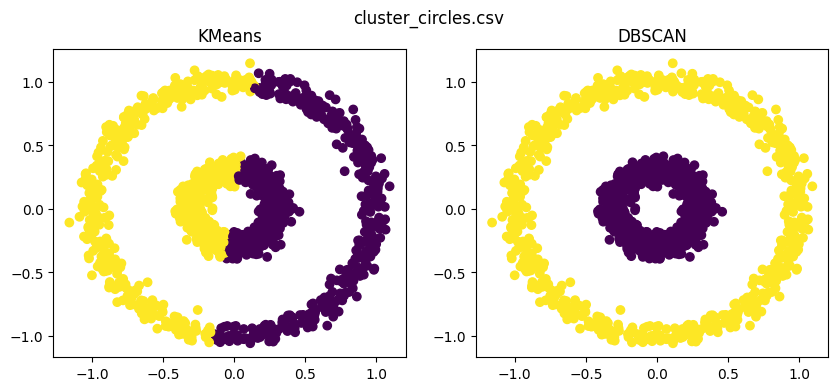

In [31]:
for file in datasets:

    print("\nDataset:", file)

    df = pd.read_csv(file)

    X = df.values

    # KMeans
    kmeans = KMeans(n_clusters=2, random_state=42)
    k_labels = kmeans.fit_predict(X)

    # Choose eps based on dataset
    if "blobs" in file:
        eps = 0.5
    elif "moons" in file:
        eps = 0.25
    elif "circles" in file:
        eps = 0.15
        
    # DBSCAN
    dbscan = DBSCAN(eps=eps ,min_samples=5)
    d_labels = dbscan.fit_predict(X)

    #Visualization
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.scatter(X[:,0], X[:,1], c=k_labels)
    plt.title("KMeans")

    plt.subplot(1,2,2)
    plt.scatter(X[:,0], X[:,1], c=d_labels)
    plt.title("DBSCAN")

    plt.suptitle(file)
    plt.show()


In [14]:
df_blobs = pd.read_csv("cluster_two_blobs.csv")
df_outliers = pd.read_csv("cluster_two_blobs_outliers.csv")


In [15]:
print("\nFirst Dataset:")
print(df_blobs.head())


First Dataset:
         X1        X2
0  0.046733  1.765120
1 -8.994134 -6.508186
2  0.650539  1.264533
3 -9.501554 -6.736493
4  0.057050  0.188215


In [16]:
print("\nSecond Dataset:")
print(df_outliers.head())


Second Dataset:
         X1        X2
0  0.046733  1.765120
1 -8.994134 -6.508186
2  0.650539  1.264533
3 -9.501554 -6.736493
4  0.057050  0.188215


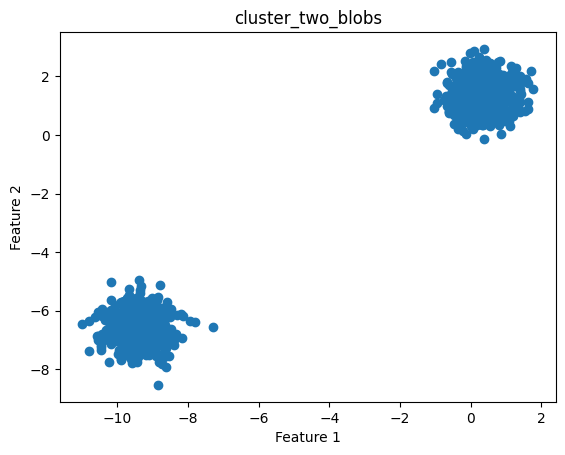

In [17]:
plt.figure()
plt.scatter(df_blobs.iloc[:,0], df_blobs.iloc[:,1])
plt.title("cluster_two_blobs")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

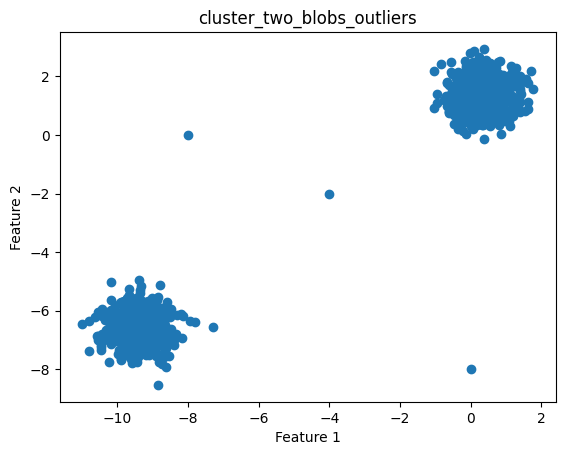

In [18]:
plt.figure()
plt.scatter(df_outliers.iloc[:,0], df_outliers.iloc[:,1])
plt.title("cluster_two_blobs_outliers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


DBSCAN with eps = 10
Clusters found: 1


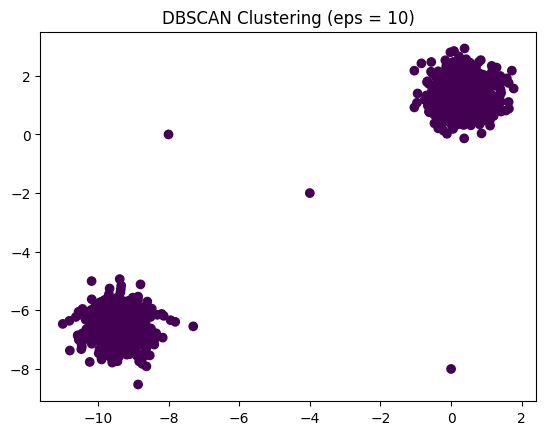


DBSCAN with eps = 7
Clusters found: 2


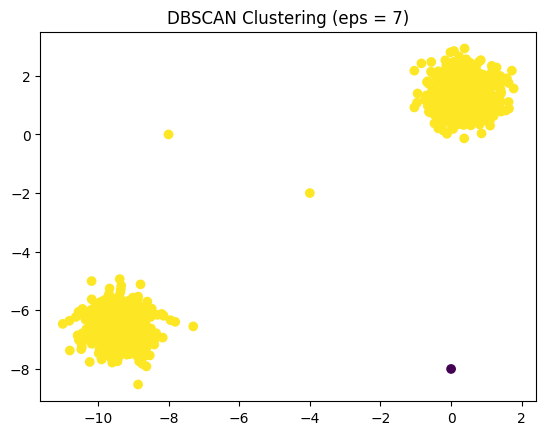


DBSCAN with eps = 0.001
Clusters found: 1


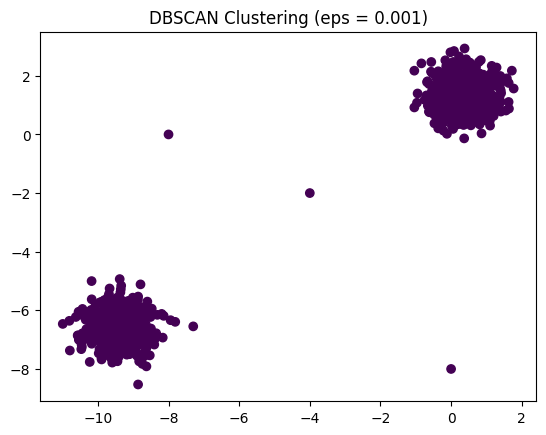


DBSCAN with eps = 1
Clusters found: 3


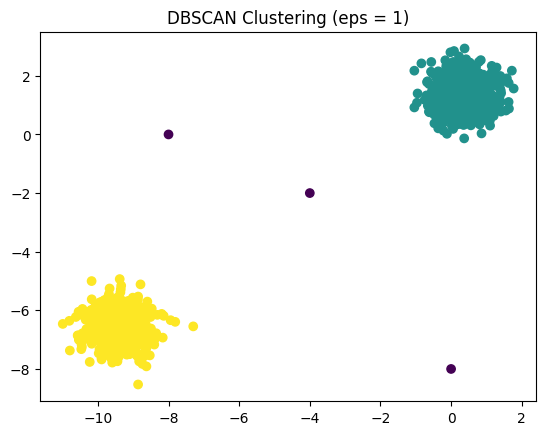

In [19]:
X = df_outliers.values

eps_values = [10, 7, 0.001, 1]

for eps in eps_values:

    dbscan = DBSCAN(eps=eps)
    labels = dbscan.fit_predict(X)

    print("\nDBSCAN with eps =", eps)
    print("Clusters found:", len(set(labels)))

    plt.figure()
    plt.scatter(X[:,0], X[:,1], c=labels)
    plt.title(f"DBSCAN Clustering (eps = {eps})")
    plt.show()